In [2]:
import json
import pandas as pd
from pathlib import Path
from sentence_transformers import SentenceTransformer, util

# --- 1. Load Model ---
model_transformer = SentenceTransformer("all-MiniLM-L6-v2")

# Fungsi helper untuk load json biar tidak repetitif
def load_json_data(filename):
    p = Path(filename)
    if not p.exists():
        raise FileNotFoundError(f"{p} not found")
    
    try:
        return pd.read_json(p)
    except ValueError:
        try:
            return pd.read_json(p, lines=True)
        except ValueError:
            with p.open("r", encoding="utf-8") as f:
                data = json.load(f)
            return pd.json_normalize(data)

# Fungsi helper untuk clean text
def create_text_column(df):
    # Pastikan string, isi NA dengan string kosong
    df['summary'] = df['summary'].fillna('').astype(str)
    df['description'] = df['description'].fillna('').astype(str)
    
    # Logic penambahan titik
    df['summary'] = df['summary'].apply(lambda x: x + '.' if x and not x.strip().endswith('.') else x)
    df['description'] = df['description'].apply(lambda x: x + '.' if x and not x.strip().endswith('.') else x)
    
    # Gabung text
    df['text'] = (df['summary'] + ' ' + df['description']).str.strip()
    return df

# --- 2. Load & Prepare Data Utama (Graphs) ---
print("Loading graphs.json...")
df = load_json_data("graphs.json")
df = create_text_column(df)

# --- 3. Load & Prepare Data Features (Reference) ---
print("Loading features.json...")
df_feat = load_json_data("features.json")
df_feat = create_text_column(df_feat)

# --- 4. Encoding (Batch Process - Optimized) ---
print("Generating embeddings...")

# Encode sekaligus (Batch). Ini JAUH lebih cepat daripada .apply()
# Hasilnya langsung berupa PyTorch Tensor karena convert_to_tensor=True
issue_embeddings = model_transformer.encode(df['text'].tolist(), convert_to_tensor=True)
feature_embeddings = model_transformer.encode(df_feat['text'].tolist(), convert_to_tensor=True)

# --- 5. Calculate Similarity ---
# Input berupa Tensor, Output berupa Tensor (n_samples_a, n_samples_b)
print("Calculating cosine similarity...")
sim_scores_tensor = util.pytorch_cos_sim(issue_embeddings, feature_embeddings)

# Pindahkan ke CPU dan ubah ke numpy agar bisa masuk Pandas
sim_scores = sim_scores_tensor.cpu().numpy()

# --- 6. Masukkan ke DataFrame ---
# Loop sebanyak jumlah kolom features (df_feat)
# sim_scores shape: (100, 3) -> (baris_df, baris_df_feat)
for i in range(sim_scores.shape[1]):
    col_name = f'feat_{i}'
    # Ambil seluruh baris untuk kolom ke-i
    df[col_name] = sim_scores[:, i]

# --- 7. Hasil ---
print("Shape akhir:", df.shape)
display(df.head())

Loading graphs.json...
Loading features.json...
Generating embeddings...
Calculating cosine similarity...
Shape akhir: (3621, 13)


,key,summary,description,components,project,issuetype,priority,status,reporter,methods,text,feat_0,feat_1
0,AMQ-3189,"Postgresql with spring embedded activeMQ has ""...",This may not a bug as MQ is still workable aft...,[],ActiveMQ Classic,Improvement,Major,Resolved,steve neo,"[java.io.IOException, java.sql.ResultSet, java...","Postgresql with spring embedded activeMQ has ""...",0.381231,0.098871
1,AMQ-3452,add 'stop' goal to the maven-activemq-plugin.,This would be useful in at least two scenarios...,[],ActiveMQ Classic,New Feature,Major,Resolved,Paulo Siqueira,"[java.util.Properties, org.apache.activemq.bro...",add 'stop' goal to the maven-activemq-plugin. ...,1.000000,-0.011226
2,AMQ-4509,activemq-maven-plugin should have a stop goal.,The maven-activemq-plugin (aka activemq-maven-...,[Broker],ActiveMQ Classic,New Feature,Minor,Resolved,Tim Andersen,"[java.util.Properties, org.apache.activemq.bro...",activemq-maven-plugin should have a stop goal....,0.774972,-0.036995
3,AMQ-5024,Add paging of messages to the webconsole when ...,It is not feasible to browse a deep Queue via ...,[WebConsole],ActiveMQ Classic,Improvement,Major,Closed,Arthur Naseef,"[java.io.File, java.io.FileInputStream, java.i...",Add paging of messages to the webconsole when ...,0.181760,0.087899
4,AMQ-5137,make networkConnector decreaseNetworkConsumerP...,"It makes sense to bias local consumers, to avo...",[],ActiveMQ Classic,Improvement,Major,Resolved,Gary Tully,"[junit.framework.TestCase, org.apache.activemq...",make networkConnector decreaseNetworkConsumerP...,0.200196,0.020685


In [3]:
# List untuk menampung hasil
results = {}

# Tentukan berapa banyak top data yang mau diambil (misal Top 3)
top_n = 5

blacklists = ["java.io", "java.util", "java.lang", "org.apache.maven", "org.junit", "org.slf4j", "org.springframework", "java.net"]

feat_cols = [c for c in df.columns if c.startswith('feat_')]

for col in feat_cols:
    # Urutkan berdasarkan kolom fitur tersebut (Descending)
    sorted_df = df.sort_values(by=col, ascending=False).head(top_n).reset_index(drop=True)
    
    # Simpan 'methods' (atau ID) dan 'score' ke dictionary
    results[f'{col}_key'] = sorted_df['key']
    results[f'{col}_score'] = sorted_df[col]
    results[f'{col}_method'] = sorted_df['methods']

    # Tampilkan hasil
    methods = []
    feat_key = df_feat.loc[int(col.split('_')[1]), 'key']
    print(f"\nTop {top_n} recommendation methods for {feat_key}:")
    for idx in range(top_n):
        key = sorted_df.loc[idx, 'key']
        method = [
            item for item in sorted_df.loc[idx, 'methods']
            if not any(item.startswith(b_item) for b_item in blacklists)
        ]
        methods = list(dict.fromkeys(methods + method))
        score = sorted_df.loc[idx, col]
        print(f"{idx + 1}. Key: {key} | Score: {score:.2f} | Method: {method}")
    
    # Filter out blacklisted methods
    methods = [
        item for item in methods 
        if not any(item.startswith(b_item) for b_item in blacklists)
    ]
    print(f"Methods List: {methods}")

# Buat DataFrame dari dictionary
# df_top_ranks = pd.DataFrame(results)
# display(df_top_ranks)


Top 5 recommendation methods for FEAT-1:
1. Key: AMQ-3452 | Score: 1.00 | Method: ['org.apache.activemq.broker.BrokerFactory', 'org.apache.activemq.broker.BrokerService']
2. Key: AMQ-4509 | Score: 0.77 | Method: ['org.apache.activemq.broker.BrokerFactory', 'org.apache.activemq.broker.BrokerService']
3. Key: AMQ-6706 | Score: 0.61 | Method: ['org.apache.activemq.broker.BrokerService', 'org.apache.activemq.camel.component.ActiveMQComponent', 'org.apache.camel.CamelContext', 'org.apache.camel.CamelContextAware', 'org.apache.camel.Exchange', 'org.apache.camel.Processor', 'org.apache.camel.ProducerTemplate', 'org.apache.camel.builder.RouteBuilder', 'org.apache.camel.impl.DefaultCamelContext']
4. Key: AMQ-5294 | Score: 0.52 | Method: ['java.nio.ByteBuffer', 'java.nio.channels.Channels', 'java.nio.channels.WritableByteChannel', 'java.security.SecureRandom', 'java.security.cert.CertificateException', 'java.security.cert.X509Certificate', 'javax.jms.Connection', 'javax.jms.ConnectionFactory', 

In [4]:
# --- Import Library Machine Learning (Scikit-Learn) ---
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

print("--- Memulai Task Klasifikasi Prioritas ---")

# 1. Persiapan Data
# Kita ambil embeddings yang sudah dibuat sebelumnya sebagai fitur (X)
# .cpu().numpy() diperlukan karena issue_embeddings adalah PyTorch Tensor
X = issue_embeddings.cpu().numpy()
y = df['priority']  # Label target yang ingin diprediksi

# Cek distribusi label (agar tahu seberapa seimbang datanya)
print("Distribusi data per prioritas:")
print(y.value_counts())

# 2. Membagi Data (Split)
# 80% data untuk melatih model (Training), 20% untuk ujian (Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Melatih Model
# Kita gunakan Logistic Regression karena cepat dan efektif untuk data teks/embedding
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)

# 4. Evaluasi / Pengujian
# Minta model memprediksi data ujian yang belum pernah dilihatnya
y_pred = clf.predict(X_test)

# Tampilkan hasil rapornya
print("\n--- Hasil Evaluasi Model ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetail Laporan Klasifikasi:")
print(classification_report(y_test, y_pred))

--- Memulai Task Klasifikasi Prioritas ---
Distribusi data per prioritas:
priority
Major       2457
Minor        937
Trivial       95
Critical      92
Blocker       40
Name: count, dtype: int64

--- Hasil Evaluasi Model ---
Akurasi: 0.40

Detail Laporan Klasifikasi:
              precision    recall  f1-score   support

     Blocker       0.01      0.10      0.03        10
    Critical       0.07      0.47      0.12        15
       Major       0.74      0.41      0.53       497
       Minor       0.37      0.37      0.37       184
     Trivial       0.07      0.32      0.11        19

    accuracy                           0.40       725
   macro avg       0.25      0.33      0.23       725
weighted avg       0.61      0.40      0.46       725



In [5]:
# --- Import Library Machine Learning (Scikit-Learn) ---
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

print("--- Memulai Task Klasifikasi Issue Types ---")

# 1. Persiapan Data
# Kita ambil embeddings yang sudah dibuat sebelumnya sebagai fitur (X)
# .cpu().numpy() diperlukan karena issue_embeddings adalah PyTorch Tensor
X = issue_embeddings.cpu().numpy()
y = df['issuetype']  # Label target yang ingin diprediksi

# Cek distribusi label (agar tahu seberapa seimbang datanya)
print("Distribusi data per issue type:")
print(y.value_counts())

# 2. Membagi Data (Split)
# 80% data untuk melatih model (Training), 20% untuk ujian (Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Melatih Model
# Kita gunakan Logistic Regression karena cepat dan efektif untuk data teks/embedding
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)

# 4. Evaluasi / Pengujian
# Minta model memprediksi data ujian yang belum pernah dilihatnya
y_pred = clf.predict(X_test)

# Tampilkan hasil rapornya
print("\n--- Hasil Evaluasi Model ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetail Laporan Klasifikasi:")
print(classification_report(y_test, y_pred, zero_division=0))

--- Memulai Task Klasifikasi Issue Types ---
Distribusi data per issue type:
issuetype
Improvement    3011
New Feature     602
Wish              8
Name: count, dtype: int64

--- Hasil Evaluasi Model ---
Akurasi: 0.75

Detail Laporan Klasifikasi:
              precision    recall  f1-score   support

 Improvement       0.93      0.76      0.84       606
 New Feature       0.36      0.73      0.48       117
        Wish       0.00      0.00      0.00         2

    accuracy                           0.75       725
   macro avg       0.43      0.49      0.44       725
weighted avg       0.84      0.75      0.78       725



In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score

print("--- Memulai Component Prediction (Optimized) ---")

# --- 1. Persiapan Data (Input X dan Target y) ---

# Pastikan X dalam format Numpy (bukan Tensor)
# Mengambil dari issue_embeddings yang sudah dibuat di sel awal notebook
if 'issue_embeddings' in locals():
    try:
        X = issue_embeddings.cpu().numpy()
    except AttributeError:
        X = np.array(issue_embeddings)
else:
    # Jika issue_embeddings tidak ditemukan, pastikan Anda sudah run sel embedding
    raise ValueError("Variabel 'issue_embeddings' tidak ditemukan. Jalankan sel embedding terlebih dahulu.")

# Pastikan kolom components berisi list, jika NaN ganti dengan []
components_data = df['components'].apply(lambda x: x if isinstance(x, list) else [])

# Ubah list teks menjadi matriks biner (0/1)
mlb = MultiLabelBinarizer()
y_raw = mlb.fit_transform(components_data)

# --- 2. Filter Komponen Langka ---
# Hitung jumlah data per komponen
comp_counts = y_raw.sum(axis=0)

# Aturan: Komponen harus muncul minimal 5 kali agar dipelajari
min_count = 5
valid_indices = np.where(comp_counts >= min_count)[0]

# Filter data target (hanya ambil kolom yang lolos seleksi)
y_filtered = y_raw[:, valid_indices]
valid_classes = mlb.classes_[valid_indices]  # Simpan nama kelas yang valid

print(f"Jumlah komponen awal  : {len(mlb.classes_)}")
print(f"Jumlah setelah filter : {len(valid_classes)} (Min. {min_count} data)")
print(f"Komponen dibuang      : {len(mlb.classes_) - len(valid_classes)}")

# --- 3. Split Data Training & Testing ---
X_train, X_test, y_train, y_test = train_test_split(X, y_filtered, test_size=0.2, random_state=42)

# --- 4. Training Model (Logistic Regression Balanced) ---
print("\nMelatih Model (Logistic Regression dengan penyeimbang data)...")
# Solver 'liblinear' bagus untuk dimensi tinggi, 'balanced' memperbaiki bias ke kelas mayoritas
clf = OneVsRestClassifier(LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
    random_state=42,
    max_iter=1000
))
clf.fit(X_train, y_train)

# --- 5. Evaluasi & Metrik ---
print("Menghitung hasil prediksi...")
y_pred = clf.predict(X_test)

# Hitung Metrik Utama
acc_subset = accuracy_score(y_test, y_pred)
f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"\n--- HASIL EVALUASI AKHIR ---")
print(f"Subset Accuracy            : {acc_subset:.2f} (Tebakan harus 100% sempurna per baris)")
print(f"F1-Score Micro (Global)    : {f1_micro:.2f} (Akurasi umum)")
print(f"F1-Score Macro (Rata-rata) : {f1_macro:.2f} (Seberapa bagus model mengenali komponen kecil)")

# --- 6. Helper: Manual Inverse Transform ---
# Fungsi untuk mengembalikan [0, 1, 0] menjadi ['KomponenB']
def get_labels(binary_row, label_names):
    return [label_names[i] for i, val in enumerate(binary_row) if val == 1]

# Contoh Prediksi
print("\n--- Contoh Prediksi Data Pertama ---")
sample_pred = get_labels(y_pred[0], valid_classes)
sample_true = get_labels(y_test[0], valid_classes)
print(f"Prediksi AI : {sample_pred}")
print(f"Data Asli   : {sample_true}")

# --- 7. Laporan Detail Per Komponen ---
print("\n--- Top 15 Komponen (Berdasarkan jumlah data) ---")
print(f"{'KOMPONEN':<30} | {'DATA':<5} | {'F1-SCORE':<5}")
print("-" * 50)

# Hitung count berdasarkan data yang sudah difilter
counts_filtered = y_filtered.sum(axis=0)
sorted_idx = counts_filtered.argsort()[::-1]  # Urutkan dari terbanyak

for i in sorted_idx[:15]:  # Tampilkan 15 teratas
    name = valid_classes[i]
    count = counts_filtered[i]
    
    # Skor per kolom
    score = f1_score(y_test[:, i], y_pred[:, i], average='binary', zero_division=0)
    
    print(f"{name:<30} | {count:<5} | {score:.2f}")

--- Memulai Component Prediction (Optimized) ---
Jumlah komponen awal  : 120
Jumlah setelah filter : 70 (Min. 5 data)
Komponen dibuang      : 50

Melatih Model (Logistic Regression dengan penyeimbang data)...
Menghitung hasil prediksi...

--- HASIL EVALUASI AKHIR ---
Subset Accuracy            : 0.19 (Tebakan harus 100% sempurna per baris)
F1-Score Micro (Global)    : 0.45 (Akurasi umum)
F1-Score Macro (Rata-rata) : 0.26 (Seberapa bagus model mengenali komponen kecil)

--- Contoh Prediksi Data Pertama ---
Prediksi AI : ['PySpark', 'SparkCore']
Data Asli   : ['PySpark']

--- Top 15 Komponen (Berdasarkan jumlah data) ---
KOMPONEN                       | DATA  | F1-SCORE
--------------------------------------------------
SQL                            | 1092  | 0.75
SparkCore                      | 493   | 0.50
ML                             | 213   | 0.65
MLlib                          | 184   | 0.43
PySpark                        | 183   | 0.66
Build                          | 96    | 0

--- Memulai Clustering (K-Means + t-SNE) ---
Melakukan grouping menjadi 5 cluster...
Menjalankan t-SNE (Mungkin butuh 1-2 menit)...


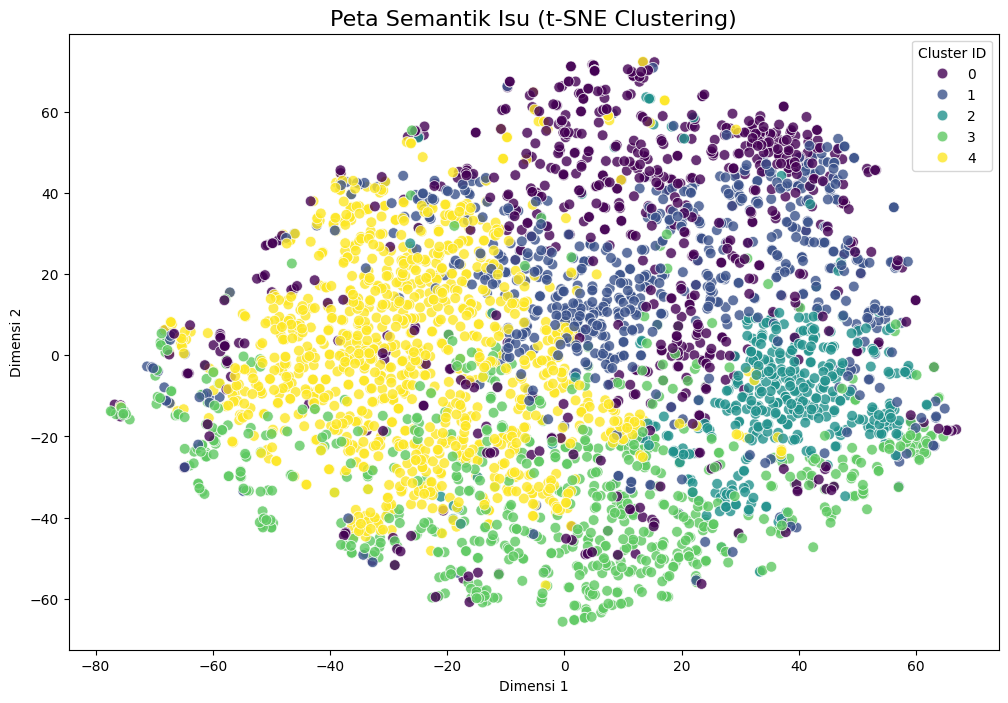


--- Analisis Topik per Cluster ---
Kami mengambil sampel judul isu untuk memahami topik setiap grup:

Cluster 0:
  - Expose  stageAttemptId in TaskContext.
  - JavaStreamingContext#awaitTermination() throws non-declared InterruptedException.
  - Log Tez Task DAG ID, DAG Session ID, HS2 Hostname.
  - Remove deprecated methods; fix two other warnings.
  - Python example code for Multilayer Perceptron Classification.
----------------------------------------
Cluster 1:
  - Method SGDOptimizer and LBFGSOptimizer in FeedForwardTrainer should not create new optimizer every time they got invoked.
  - Providing ExternalSet to avoid OOM when count(distinct).
  - BlockFetcher should retry while getting OutOfDirectMemoryError.
  - Config the start time (jitter) for streaming jobs.
  - Reimplement delta file metric collection.
----------------------------------------
Cluster 2:
  - Use LLAP to get orc metadata.
  - partition_explain_ddl.q is flaky.
  -  Iceberg REST Catalog client.
  - HiveJoinAdd

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# --- DISABLE WARNING: Matikan parallelism tokenizers ---
# Harus diset SEBELUM melakukan import library lain atau training
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("--- Memulai Clustering (K-Means + t-SNE) ---")

# 1. Persiapan Data
# Pastikan X (embeddings) sudah ada
if 'issue_embeddings' in locals():
    # Convert tensor to numpy if needed
    try:
        X = issue_embeddings.cpu().numpy()
    except AttributeError:
        X = np.array(issue_embeddings)
else:
    raise ValueError("Variabel 'issue_embeddings' tidak ditemukan.")

# 2. Menentukan Jumlah Cluster (K)
# Kita coba 5 cluster utama dulu
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

print(f"Melakukan grouping menjadi {n_clusters} cluster...")
cluster_labels = kmeans.fit_predict(X)

# Simpan hasil cluster ke DataFrame sementara untuk analisis
df_cluster = df.copy()
df_cluster['cluster'] = cluster_labels

# 3. Reduksi Dimensi untuk Visualisasi (t-SNE)
# Embeddings punya 384 dimensi, kita persempit jadi 2 (X dan Y) agar bisa digambar
print("Menjalankan t-SNE (Mungkin butuh 1-2 menit)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X)

# 4. Visualisasi Plot
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x=X_embedded[:, 0], 
    y=X_embedded[:, 1], 
    hue=cluster_labels, 
    palette='viridis', 
    s=60, 
    alpha=0.8,
    legend='full'
)

plt.title('Peta Semantik Isu (t-SNE Clustering)', fontsize=16)
plt.xlabel('Dimensi 1')
plt.ylabel('Dimensi 2')
plt.legend(title='Cluster ID')
plt.show() # Tampilkan gambar

# 5. Analisis Kata Kunci per Cluster
print("\n--- Analisis Topik per Cluster ---")
print("Kami mengambil sampel judul isu untuk memahami topik setiap grup:\n")

for i in range(n_clusters):
    print(f"Cluster {i}:")
    # Ambil 5 contoh judul (summary) dari cluster ini
    sample_issues = df_cluster[df_cluster['cluster'] == i]['summary'].sample(5, random_state=42).values
    for issue in sample_issues:
        print(f"  - {issue}")
    print("-" * 40)

In [31]:
import os
import torch
from openai import OpenAI
from sentence_transformers import util

# 1. Setup OpenAI Client
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    print("Error: OPENAI_API_KEY environment variable not set.")
    exit(1)

client = OpenAI(
    api_key=OPENAI_API_KEY
)
available_models = client.models.list()
# print("Available Models:", [model.id for model in available_models.data])

# 2. Fungsi Pencarian (Retriever) - DENGAN AUTO-TRANSLATE
def retrieve_context(query, embeddings_db, df_db, top_k=3):
    
    # --- STEP BARU: Terjemahkan Query ke Inggris Teknis ---
    # Kita minta OpenAI mengubah pertanyaan user menjadi "Search Query" yang bagus
    translation_prompt = f"""
    Translate the following user question into a clear, technical English search query for a software issue database.
    Only output the English translation, nothing else.
    
    User Question: "{query}"
    """
    
    try:
        # Kita pakai model yang murah & cepat saja untuk ini
        trans_response = client.chat.completions.create(
            model="gpt-3.5-turbo", 
            messages=[{"role": "user", "content": translation_prompt}],
            temperature=0.3 # Rendah agar hasilnya presisi/tidak ngarang
        )
        english_query = trans_response.choices[0].message.content.strip()
        # print(f"   (Debug: Translated query -> '{english_query}')") # Uncomment jika ingin lihat prosesnya
    except Exception as e:
        # Fallback jika OpenAI error, pakai query asli
        english_query = query

    # --- Lanjut ke Proses Embedding seperti biasa ---
    # Encode pertanyaan (yang sudah jadi bahasa Inggris)
    query_embedding = model_transformer.encode(english_query, convert_to_tensor=True)
    
    # Pastikan database embeddings dalam bentuk Tensor
    if not isinstance(embeddings_db, torch.Tensor):
        embeddings_db = torch.tensor(embeddings_db)
        
    # Semantic Search
    cos_scores = util.pytorch_cos_sim(query_embedding, embeddings_db)[0]
    
    # Ambil Top-K
    top_results = torch.topk(cos_scores, k=min(top_k, len(cos_scores)))
    
    retrieved_data = []
    for score, idx in zip(top_results.values, top_results.indices):
        idx = int(idx)
        row = df_db.iloc[idx]
        
        methods = str(row['methods']) if isinstance(row['methods'], list) else "[]"
        context_str = (
            f"Ticket: {row['key']}\n"
            f"Summary: {row['summary']}\n"
            f"Technical Methods involved: {methods}\n"
            f"Relevance Score: {score:.2f}\n"
        )
        retrieved_data.append(context_str)
        
    return "\n---\n".join(retrieved_data)

# 3. Fungsi Otak (Generator) - Menggunakan LLM
def chat_with_rag(user_query, context_text):
    # System Prompt: Instruksi kepribadian si Bot
    system_prompt = """
    You are Knowledge Hub, a polite and helpful Senior Software Engineer Assistant. 
    You have access to a database of historical software issues (Jira tickets).
    
    Instructions:
    1. Identity: If the user asks "Who are you?" or "What is your name?", you MUST answer: "I am Knowledge Hub". Do not use any other name.
    2. If the user greets or chats casually (e.g., "Halo", "Apa kabar"), just reply naturally and politely in the user's language. Ignore the context.
    3. If the user asks a technical question, answer it based ONLY on the provided Context.
    4. The Context is in English, but the user might ask in Indonesian. You MUST translate the insight and answer in the user's language.
    5. If the context contains specific Java methods/classes, mention them exactly as they are (do not translate code).
    6. Be concise and professional.
    """
    
    # User Prompt: Gabungan pertanyaan user + data hasil pencarian
    user_message = f"""
    Context form Knowledge Base:
    {context_text}
    
    User Question: 
    {user_query}
    """
    
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message}
        ],
        temperature=0.7 # Agar sedikit kreatif tapi tetap faktual
    )
    
    return response.choices[0].message.content

# 4. Main Loop Chatbot (FIXED UI)
def run_smart_bot(target_embeddings, target_df):
    print("\n" + "="*60)
    print("🤖  SMART AI ASSISTANT  🤖")
    print("    Ketik 'exit' untuk keluar.")
    print("="*60)
    
    while True:
        try:
            # Input User
            query = input("\n[You]: ")
            
            if query.lower() in ['exit', 'quit', 'keluar']:
                print("\n[Bot]: Sampai jumpa! Happy coding! 👋")
                break
                
            if not query.strip():
                continue
                
            # Tampilkan Loading (tanpa newline)
            msg_loading = "⏳ Sedang berpikir & mencari data..."
            print(msg_loading, end="\r")
            
            # A. Retrieve
            context_data = retrieve_context(query, target_embeddings, target_df)
            
            # B. Generate
            ai_reply = chat_with_rag(query, context_data)
            
            # C. Tampilkan Hasil (Bersihkan baris dulu!)
            # 1. Timpa pesan loading dengan spasi kosong sepanjang pesannya
            print(" " * len(msg_loading), end="\r")
            
            # 2. Cetak jawaban Bot
            print(f"[You]: {query}")
            print(f"[Bot]: {ai_reply}")
            
        except KeyboardInterrupt:
            print("\n[Bot]: Interrupted. Bye!")
            break
        except Exception as e:
            print(f"\n[Error]: {e}")

# --- JALANKAN BOT ---
if 'issue_embeddings' in globals() and 'df' in globals():
    run_smart_bot(issue_embeddings, df)
else:
    print("❌ Error: Pastikan variabel 'issue_embeddings' dan 'df' sudah tersedia.")


🤖  SMART AI ASSISTANT  🤖
    Ketik 'exit' untuk keluar.
[You]: halo                        
[Bot]: Halo! Ada yang bisa saya bantu?
[You]: pada project activemq classic adakah tiket yang menjelaskan setup database?
[Bot]: Tidak, dari database tiket yang tersedia, tidak ada tiket yang menjelaskan setup database untuk ActiveMQ Classic.
[You]: Lakukan verifikasi checksum di tempat untuk menghindari penyalinan memori.
[Bot]: Untuk menghindari penyalinan memori saat melakukan verifikasi checksum, Anda dapat memperhatikan metode yang digunakan dalam implementasi verifikasi checksum. Pastikan untuk menghindari buffer copying agar proses verifikasi checksum lebih efisien.
[You]: tiket mana yang menjelaskan tentang verifikasi checksum di tempat untuk menghindari penyalinan memori.
[Bot]: Tiket yang menjelaskan tentang verifikasi checksum di tempat untuk menghindari penyalinan memori adalah HDDS-2204.

[Bot]: Sampai jumpa! Happy coding! 👋
